In [8]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

In [9]:
# Define the GridWorld environment (states, rewards)
grid_size = (4, 4)
terminal_states = [(0, 0), (3, 3)]
rewards = -0.1 * np.ones(grid_size)
rewards[0, 0] = 1.0
rewards[3, 3] = 1.0

# Actions: up, down, left, right
actions = ['U', 'D', 'L', 'R']
action_to_delta = {
    'U': (-1, 0),
    'D': (1, 0),
    'L': (0, -1),
    'R': (0, 1)
}

In [10]:
# Transition model: deterministic
def transition(state, action):
    if state in terminal_states:
        return state
    delta = action_to_delta[action]
    next_state = (state[0] + delta[0], state[1] + delta[1])
    if 0 <= next_state[0] < grid_size[0] and 0 <= next_state[1] < grid_size[1]:
        return next_state
    return state

In [11]:
# Value Iteration (Model-based)
def value_iteration(gamma, theta):
    global V
    while True:
        delta = 0
        new_V = np.copy(V)
        for i in range(grid_size[0]): # run through all rows
            for j in range(grid_size[1]): # run through all columns
                state = (i, j) # state given by grid location (row, column)
                if state in terminal_states: # check if current state is the terminal state
                    continue
                values = [] # initialize as an empty list
                for action in actions:
                    next_state = transition(state, action)
                    reward = rewards[next_state]
                    values.append(reward + gamma * V[next_state]) # Bellman's Equation
                best_value = max(values)
                delta = max(delta, np.abs(best_value - V[state])) # keeps track of max change of value of each state
                new_V[state] = best_value
        V = new_V
        if delta < theta:
            break

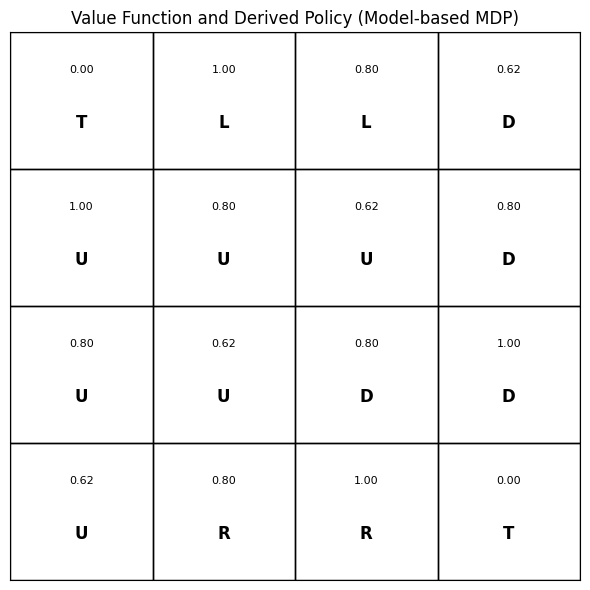

In [12]:
# Initialize value function
V = np.zeros(grid_size) # initial value of each state
gamma = 0.9 # discount factor
theta = 1e-4 # threshold

value_iteration(gamma, theta)

# Derive policy from value function (Policy Extraction)
# once we have the optimal value function, we can find the optimal poilicy by choosing, in each state, 
# the action that gives the maximum expected cummulative reward.  --> Bellman's Optimality equation. 
policy = np.full(grid_size, '', dtype=object) # create a grid of the same size of the environment
for i in range(grid_size[0]):
    for j in range(grid_size[1]):
        state = (i, j)
        if state in terminal_states:
            policy[state] = 'T'
            continue # no actions taken in terminal states
        values = []
        for action in actions:
            next_state = transition(state, action) # get the next state
            reward = rewards[next_state] # get the immediate reward
            # add the discounted future reward
            values.append((reward + gamma * V[next_state], action)) # store the total value along with action 
        best_action = max(values, key=lambda x: x[0])[1]
        policy[state] = best_action

# Plot the grid with values and policy
fig, ax = plt.subplots(figsize=(6, 6))
for i in range(grid_size[0]):
    for j in range(grid_size[1]):
        ax.add_patch(patches.Rectangle((j, grid_size[0]-1-i), 1, 1, fill=False))
        ax.text(j + 0.5, grid_size[0]-1-i + 0.7, f"{V[i, j]:.2f}", ha='center', fontsize=8)
        ax.text(j + 0.5, grid_size[0]-1-i + 0.3, policy[i, j], ha='center', fontsize=12, fontweight='bold')

ax.set_xlim(0, grid_size[1])
ax.set_ylim(0, grid_size[0])
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Value Function and Derived Policy (Model-based MDP)")
plt.grid(True)
plt.tight_layout()
plt.show()
